# Hierarchical Clustering Comparison: Correlation vs. Mutual Information vs. Chow-Liu

Five alternative figures for comparing how correlation, mutual information, and Chow-Liu trees
cluster MSC brain regions, using the motor/cerebellum/thalamus subnetwork as a test case.

| Figure | What it shows |
|--------|---------------|
| 1 | Side-by-side dendrograms colored by known network |
| 2 | Tanglegram — facing dendrograms where crossing lines show disagreement |
| 3 | Cophenetic scatter — pairwise distance agreement between methods |
| 4 | Network coherence — which method best recovers known anatomy across k |
| 5 | Co-clustering agreement — how many methods agree each region pair belongs together |

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram, fcluster, cophenet
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


## Setup — data loading (mirrors sfn_figures.ipynb)

In [2]:
home_base_dir   = '/Users/aj/dmello_lab/fmri_connectivity_trees'
lab_base_dir    = '/Users/ajjain/Downloads/Code/fmri_connectivity_trees'
utd_base_dir    = '/mfs/io/groups/dmello/projects/dynamric/fmri_connectivity_trees'
biohpc_base_dir = '/project/greencenter/Lin_lab/s229618/fmri_connectivity_trees'

base_dir = home_base_dir if os.path.exists(home_base_dir) else lab_base_dir
base_dir = utd_base_dir  if os.path.exists(utd_base_dir)  else base_dir
base_dir = biohpc_base_dir if os.path.exists(biohpc_base_dir) else base_dir

subjects     = ['MSC01', 'MSC04', 'MSC07', 'MSC09']
task         = 'rest'
num_bins     = 100
atlas_subdir = 'glasser360_SUIT_Thalamus'
other_suffix = 'func-01-10'

with open(f'{base_dir}/atlases/glasser360/glasser360NodeNames.txt') as f:
    raw = f.readlines()
glasser_labels = []
for label in raw:
    label = label.strip()
    comp  = label.split('_')
    glasser_labels.append(comp[1] + '_' + comp[0][0])

glasser_region_list = pd.read_csv(f'{base_dir}/atlases/glasser360/HCP-MMP1_UniqueRegionList.csv')
suit_labels = pd.read_csv(f'{base_dir}/atlases/SUIT/atl-Anatom.tsv', sep='\t')
all_labels  = glasser_labels + suit_labels['name'].to_list()[:-2] + ['left_global', 'right_global']


def load_data(subjects, measure, task='rest', atlas_subdir='glasser360_SUIT_Thalamus',
              num_bins=100, other_suffix='func-01-10'):
    data = {}
    for subject in subjects:
        path  = (f'{base_dir}/code/functional_connectivity/midnight_scan_club/output'
                 f'/{measure}/{subject}/{atlas_subdir}')
        fname = f'{task}_{num_bins}bins{other_suffix}'
        data[subject] = torch.from_numpy(np.load(f'{path}/{fname}.npy'))
    return data


mi_gst = load_data(subjects, measure='mutual_information',
                   task=task, atlas_subdir=atlas_subdir,
                   num_bins=num_bins, other_suffix=other_suffix)

cov    = load_data(subjects, measure='covariance',
                   task=task, atlas_subdir=atlas_subdir,
                   num_bins=num_bins, other_suffix='')


In [3]:
full_network_labels = (
    list(glasser_region_list['cortex'])
    + ['Cerebellum'] * 32
    + ['Thalamus']   * 2
)

target_networks = ['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus']

selected_nodes, node_network_labels, node_roi_names = [], [], []
for i, net in enumerate(full_network_labels):
    if net in target_networks:
        selected_nodes.append(i)
        node_network_labels.append(net)
        node_roi_names.append(all_labels[i])

N = len(selected_nodes)
print(f'{N} regions selected:', {net: node_network_labels.count(net) for net in target_networks})


44 regions selected: {'Somatosensory_and_Motor': 10, 'Cerebellum': 32, 'Thalamus': 2}


In [4]:
def chow_liu_tree(mi_matrix):
    G = nx.Graph()
    n = mi_matrix.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            G.add_edge(i, j, weight=float(mi_matrix[i, j]))
    return nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')


cl_trees = {
    subj: chow_liu_tree(mi_gst[subj].numpy()[np.ix_(selected_nodes, selected_nodes)])
    for subj in subjects
}

mi_sub  = {s: mi_gst[s].numpy()[np.ix_(selected_nodes, selected_nodes)]  for s in subjects}
cov_sub = {s: cov[s].numpy()[np.ix_(selected_nodes, selected_nodes)]      for s in subjects}
cl_adj  = {s: nx.to_numpy_array(cl_trees[s])                              for s in subjects}


NETWORK_COLORS = {
    'Somatosensory_and_Motor': "#b619e6",
    'Cerebellum':              "#000101",
    'Thalamus':                "#6F3900",
}


def condensed_corr_dist(matrix):
    d = np.clip(1.0 - matrix, 0, None)
    np.fill_diagonal(d, 0.0)
    return squareform(d, checks=False)


def condensed_mi_dist(matrix):
    norm = matrix / (matrix.max() + 1e-12)
    d = 1.0 - norm
    np.fill_diagonal(d, 0.0)
    return squareform(d, checks=False)


def condensed_cl_dist(adj_matrix):
    # All-pairs shortest-path distance in the Chow-Liu tree
    G = nx.from_numpy_array(adj_matrix)
    n = adj_matrix.shape[0]
    lengths = dict(nx.all_pairs_shortest_path_length(G))
    d = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            d[i, j] = lengths[i].get(j, n)
    np.fill_diagonal(d, 0.0)
    return squareform(d, checks=False)


def get_linkages(subject, method='average'):
    # Return (Z_corr, Z_mi, Z_cl) linkage matrices for one subject
    Z_corr = linkage(condensed_corr_dist(cov_sub[subject]), method=method)
    Z_mi   = linkage(condensed_mi_dist(mi_sub[subject]),   method=method)
    Z_cl   = linkage(condensed_cl_dist(cl_adj[subject]),   method=method)
    return Z_corr, Z_mi, Z_cl


---
## Figure 1 — Side-by-side colored dendrograms

**Idea:** One dendrogram per method; each leaf node is colored by its *known* brain network.
A good method cleanly groups same-colored leaves into the same subtrees.

**Why it's better than the matrix view:** You can immediately see whether the clustering
respects known anatomy — no need to decode a grid of numbers.

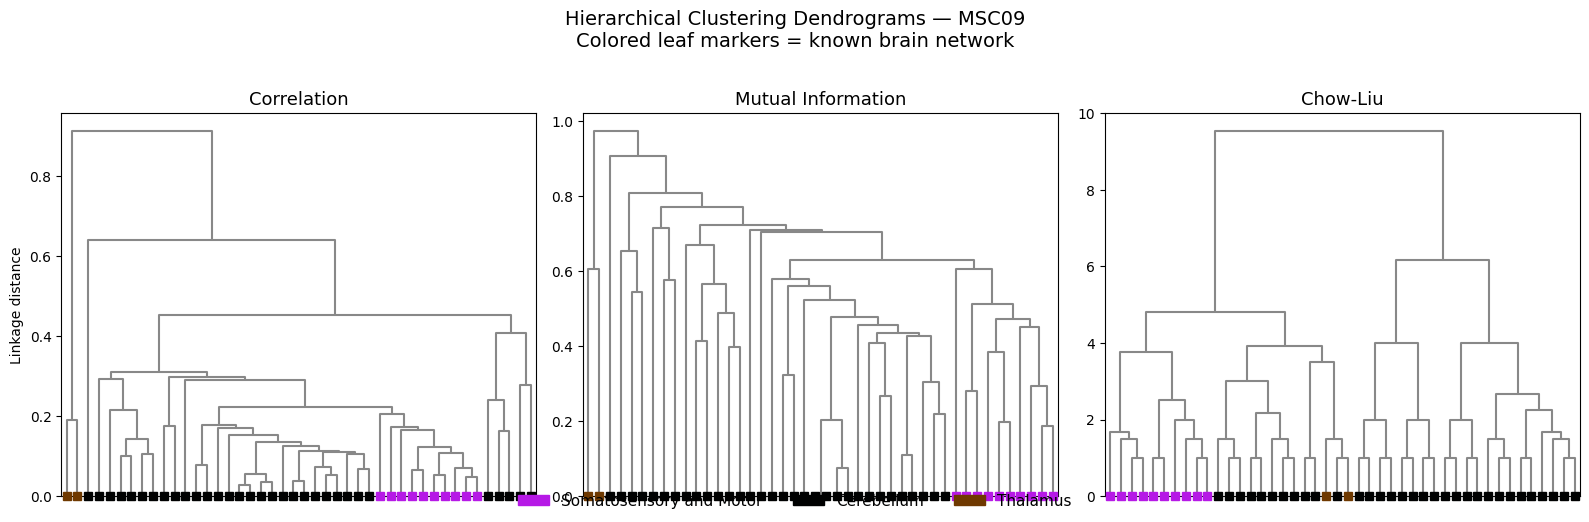

In [5]:
def plot_colored_dendrogram(Z, node_network_labels, network_colors, ax,
                             title='', marker_size=6, show_ylabel=True):
    # Dendrogram with colored square markers at each leaf indicating brain network
    dend = dendrogram(
        Z, ax=ax, orientation='top',
        color_threshold=0, above_threshold_color='#888888',
        no_labels=True
    )
    leaf_order = dend['leaves']

    # scipy leaf x-coords: 5, 15, 25, ...
    for plot_i, region_i in enumerate(leaf_order):
        x     = 5 + 10 * plot_i
        color = network_colors.get(node_network_labels[region_i], 'black')
        ax.plot(x, 0, 's', color=color, markersize=marker_size,
                transform=ax.transData, clip_on=False, zorder=5)

    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    if show_ylabel:
        ax.set_ylabel('Linkage distance', fontsize=10)
    return dend


subject = 'MSC09'
Z_corr, Z_mi, Z_cl = get_linkages(subject)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, Z, title in zip(axes,
                         [Z_corr, Z_mi, Z_cl],
                         ['Correlation', 'Mutual Information', 'Chow-Liu']):
    plot_colored_dendrogram(Z, node_network_labels, NETWORK_COLORS, ax,
                             title=title, show_ylabel=(ax is axes[0]))

legend_patches = [mpatches.Patch(color=c, label=n.replace('_', ' '))
                  for n, c in NETWORK_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=11, frameon=False)
fig.suptitle(f'Hierarchical Clustering Dendrograms — {subject}\n'
              'Colored leaf markers = known brain network',
              fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_colored_dendrograms.pdf', bbox_inches='tight')
plt.show()


---
## Figure 1b — Labeled dendrograms with colored stems

**Idea:** Same layout as Figure 1, but now:
1. **Region names** are shown at every leaf, colored by known brain network.
2. **Branches are colored by sub-cluster** (found independently by each method at k clusters).
   Branches above the cut are grey; each identified sub-cluster gets a distinct color.

Reading guide:
- If two leaves share the same branch color, that method groups them together.
- Comparing branch colors across the three panels shows where methods agree or disagree
  about the fine-grain groupings *within* each network.

**Why this beats a matrix:** You see the full hierarchy at once — which regions nest
inside which sub-clusters — rather than just pairwise distances.

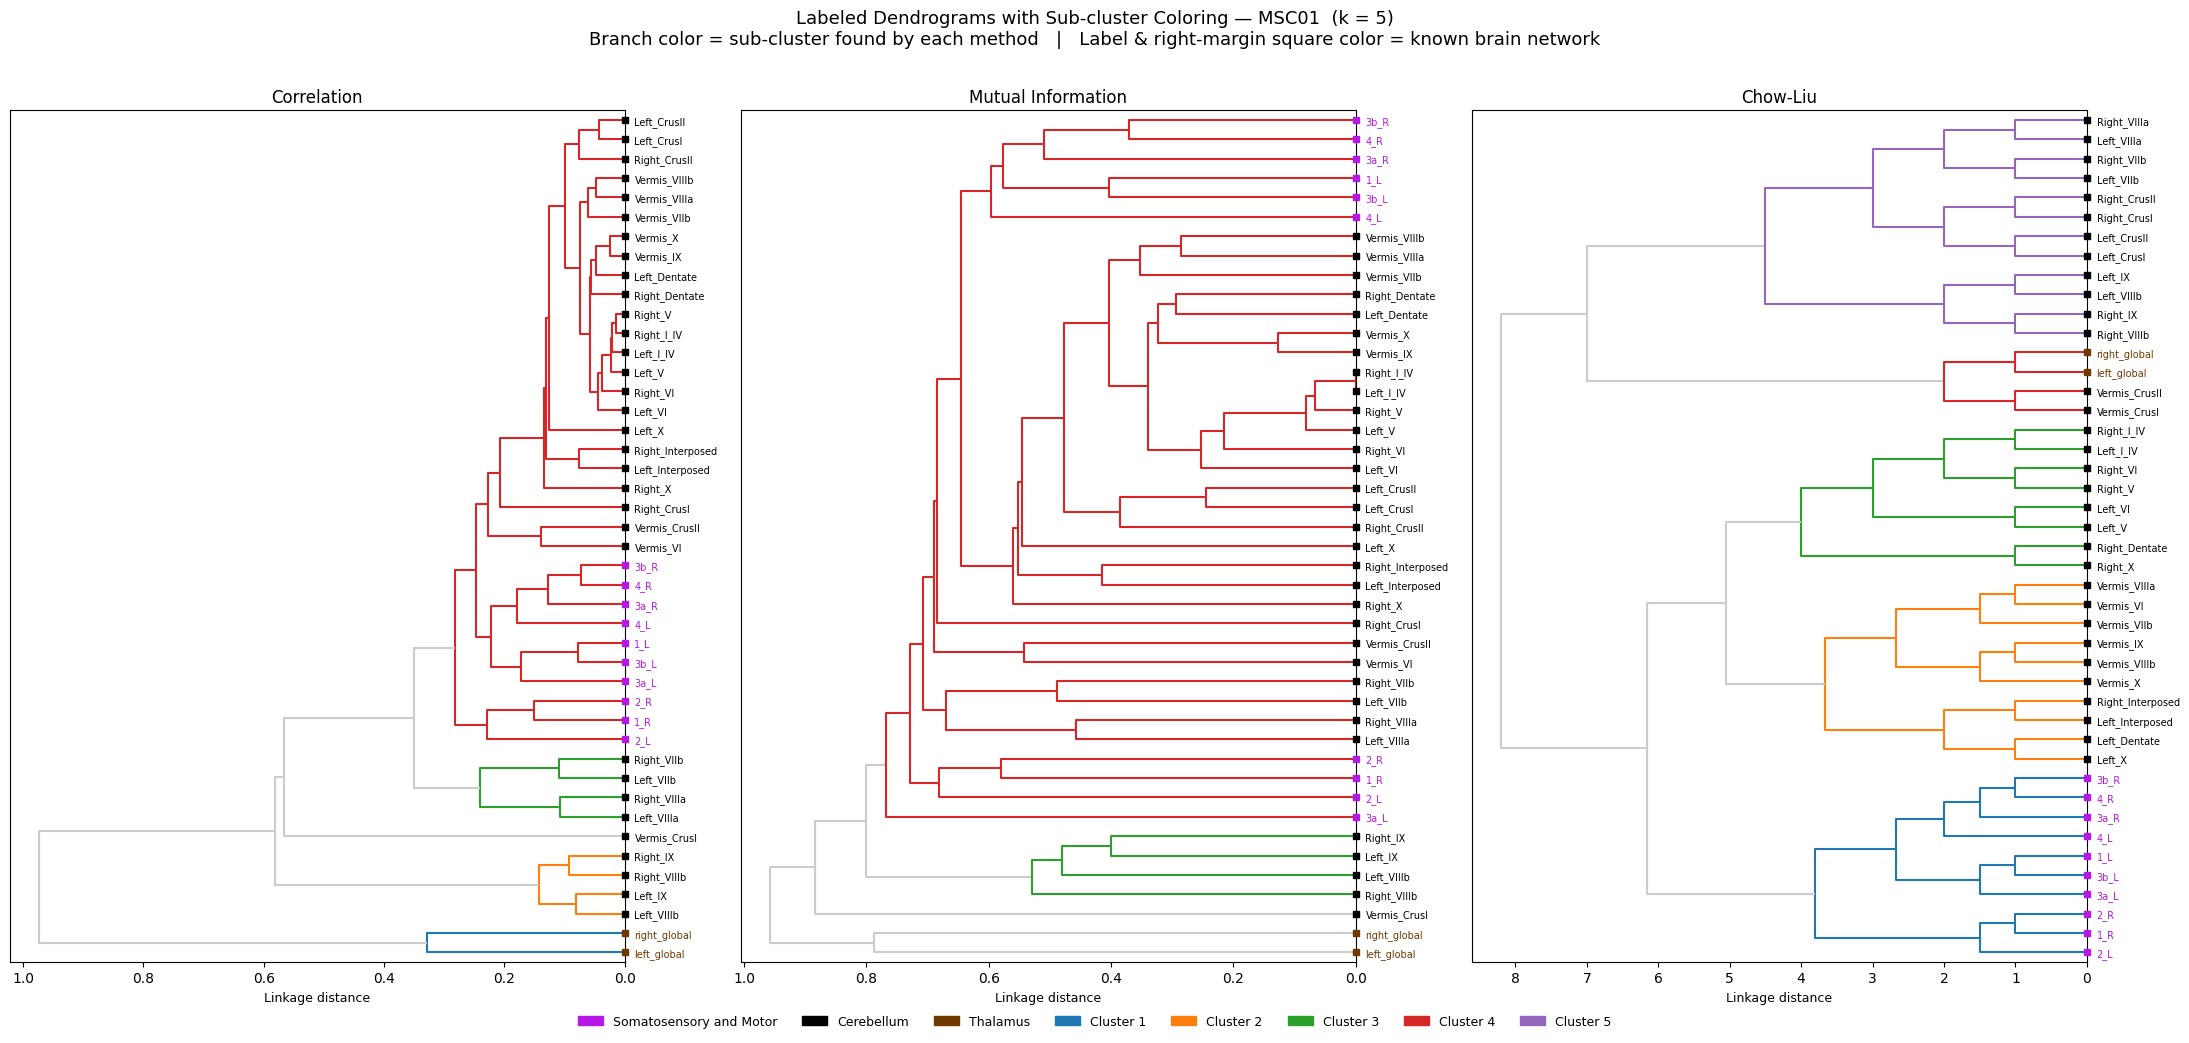

In [11]:
import matplotlib.colors as mcolors


def plot_labeled_dendrogram(Z, node_network_labels, node_roi_names,
                             network_colors, ax, title='', k_sub=5,
                             cluster_palette=None, leaf_font_size=7):
    # Build link_color_func from k-cluster fcluster assignments
    n = len(node_network_labels)

    if cluster_palette is None:
        tab10 = plt.cm.tab10.colors
        cluster_palette = {i + 1: mcolors.to_hex(tab10[i]) for i in range(k_sub)}

    leaf_clusters = fcluster(Z, t=k_sub, criterion='maxclust')

    # For each node (leaf or internal), determine which single cluster it belongs
    # to (or None if it spans multiple clusters = above the cut).
    node_cluster = {i: int(leaf_clusters[i]) for i in range(n)}
    for i in range(len(Z)):
        left   = int(Z[i, 0])
        right  = int(Z[i, 1])
        parent = n + i
        cl_l = node_cluster.get(left)
        cl_r = node_cluster.get(right)
        node_cluster[parent] = cl_l if (cl_l is not None and cl_l == cl_r) else None

    def link_color_func(k):
        # k is the child node ID whose incoming link is being colored
        cluster = node_cluster.get(int(k))
        if cluster is None:
            return '#cccccc'   # grey: this link is above the cut
        c = cluster_palette.get(cluster, '#888888')
        return c if isinstance(c, str) else mcolors.to_hex(c[:3])

    # orientation='left': root at left, branches grow right, leaves (labels) at right
    dend = dendrogram(
        Z, ax=ax,
        orientation='left',
        labels=node_roi_names,
        leaf_font_size=leaf_font_size,
        link_color_func=link_color_func,
    )

    leaf_order = dend['leaves']

    # Color leaf labels by known brain network
    for lbl, region_i in zip(ax.get_yticklabels(), leaf_order):
        lbl.set_color(network_colors.get(node_network_labels[region_i], 'black'))

    # Add a colored network strip on the right margin (outside the axes)
    n_regions = len(leaf_order)
    strip_x   = ax.get_xlim()[1] * 1.02    # just to the right of the tree
    for plot_i, region_i in enumerate(leaf_order):
        y     = 5 + 10 * plot_i
        color = network_colors.get(node_network_labels[region_i], 'black')
        ax.plot(strip_x, y, 's', color=color, markersize=5,
                transform=ax.transData, clip_on=False, zorder=5)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Linkage distance', fontsize=9)
    return dend, leaf_clusters


# ---- Parameters ----
k_sub   = 5    # number of sub-clusters to highlight
subject = 'MSC01'

Z_corr, Z_mi, Z_cl = get_linkages(subject)
n_regions = len(node_network_labels)

# Shared cluster palette so the same cluster index = same color across methods
tab10           = plt.cm.tab10.colors
cluster_palette = {i + 1: mcolors.to_hex(tab10[i]) for i in range(k_sub)}

fig_height = max(10, n_regions * 0.19)
fig, axes  = plt.subplots(1, 3, figsize=(22, fig_height))

for ax, Z, title in zip(axes,
                         [Z_corr, Z_mi, Z_cl],
                         ['Correlation', 'Mutual Information', 'Chow-Liu']):
    plot_labeled_dendrogram(
        Z, node_network_labels, node_roi_names, NETWORK_COLORS, ax,
        title=title, k_sub=k_sub, cluster_palette=cluster_palette,
        leaf_font_size=7
    )

net_patches     = [mpatches.Patch(color=c, label=n.replace('_', ' '))
                   for n, c in NETWORK_COLORS.items()]
cluster_patches = [mpatches.Patch(color=cluster_palette[i + 1], label=f'Cluster {i + 1}')
                   for i in range(k_sub)]
fig.legend(handles=net_patches + cluster_patches,
           loc='lower center', ncol=len(net_patches) + k_sub,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    f'Labeled Dendrograms with Sub-cluster Coloring — {subject}  (k = {k_sub})\n'
    'Branch color = sub-cluster found by each method   |   '
    'Label & right-margin square color = known brain network',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('fig1b_labeled_dendrograms.pdf', bbox_inches='tight')
plt.show()


---
## Figure 1c — Labeled dendrograms with shared leaf order

**Idea:** Same as Figure 1b, but all three panels are forced to display leaves in the
**same order** (the order found by the correlation dendrogram).  
Branches are still colored by each method's own k-cluster assignment.

This makes column-by-column comparison trivial:
- A region that is in the same colored block in all three panels is
  consistently grouped across methods.
- A region whose branch color changes across panels is the contentious one.

A colored cluster-assignment strip is appended to the right of each panel
so you can read off cluster membership without tracing branches.

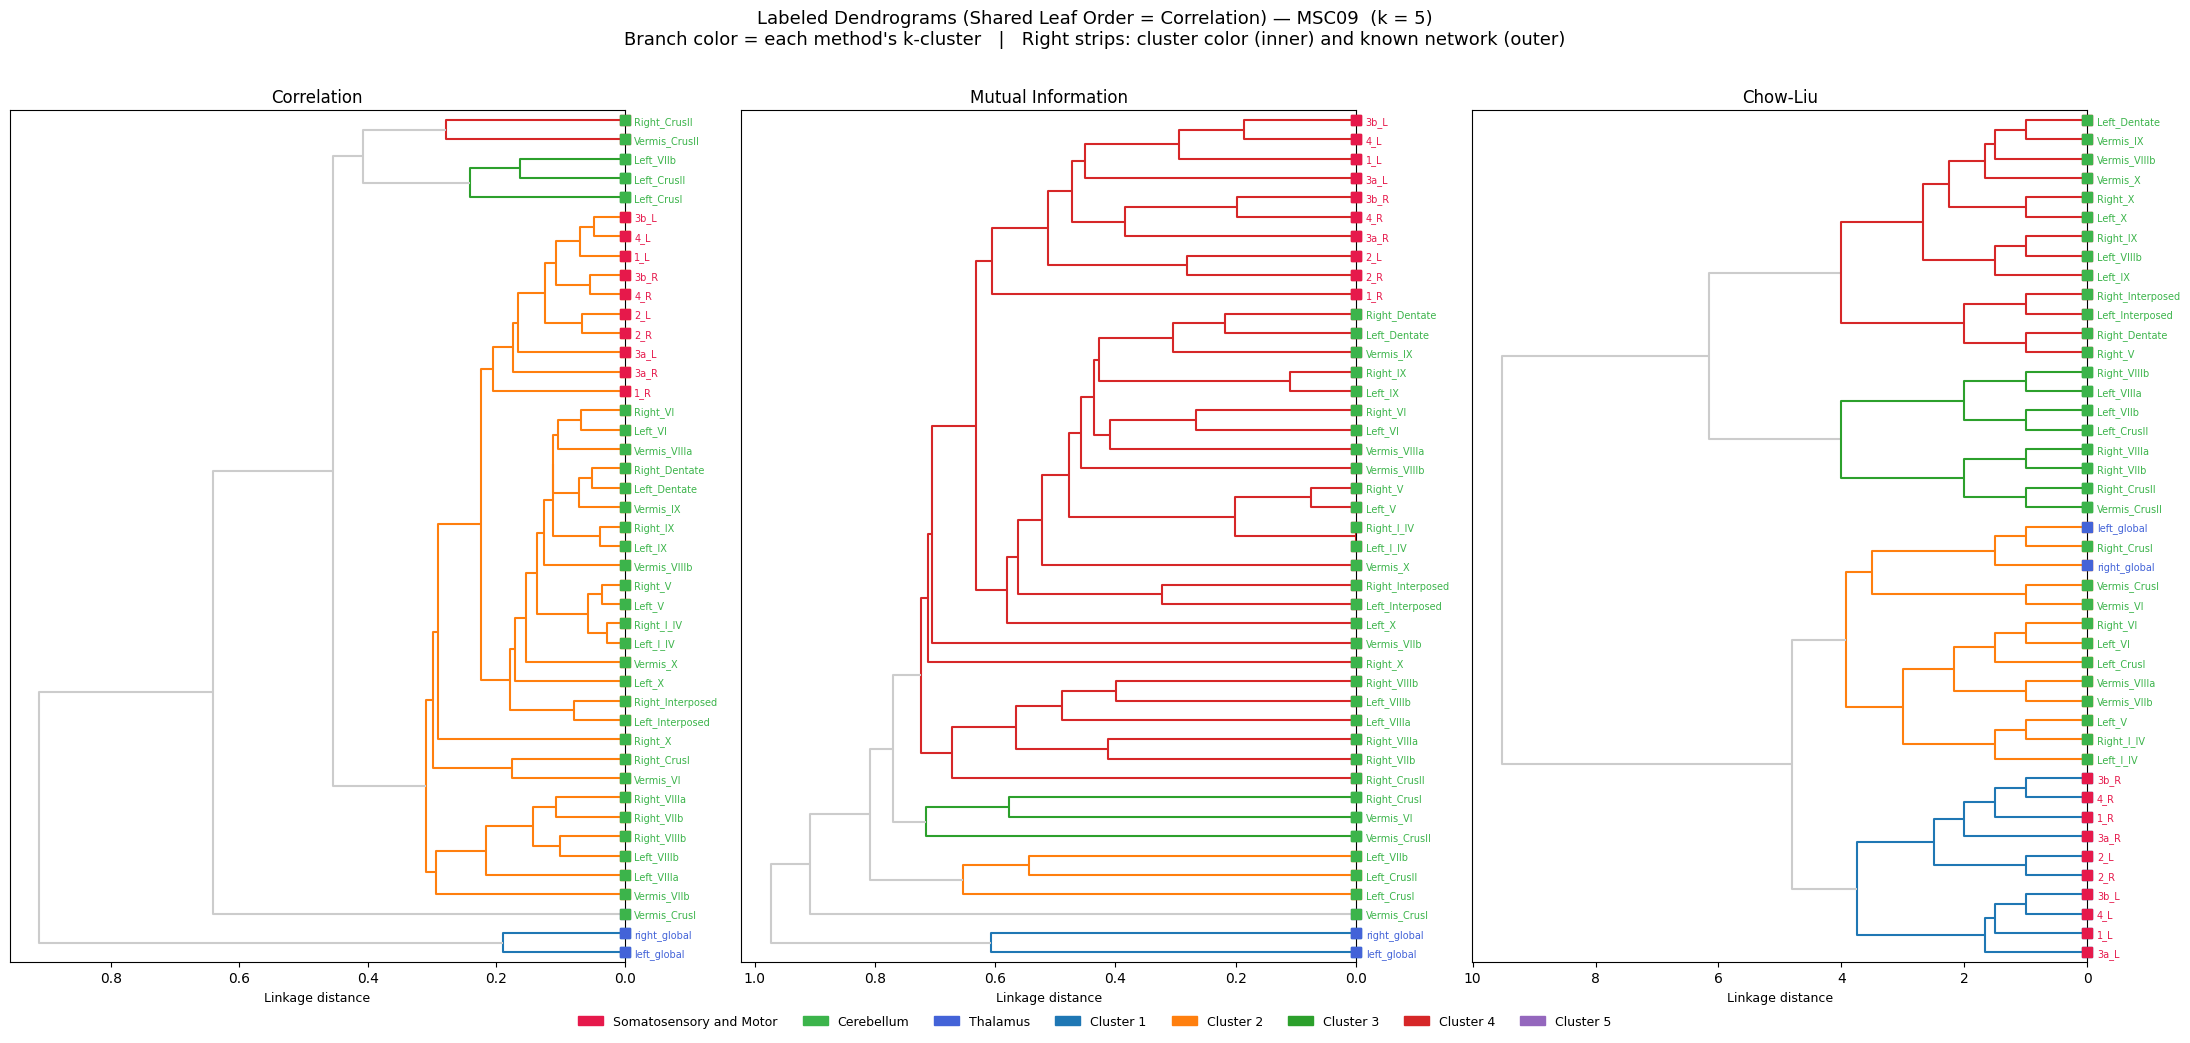

In [13]:
def reorder_linkage_to_match(Z, target_order):
    """
    Rotate the children of every internal node in Z so the leaf traversal order
    best matches target_order.

    For each merge (bottom-up), we compare the mean target-position of the left
    and right subtrees and swap them if the left subtree has a higher mean target
    position than the right.  This is the standard dendrogram-rotation trick and
    produces the valid linearisation of each tree that is closest to target_order.

    Returns a new linkage matrix (same distances, potentially swapped child columns).
    """
    n = Z.shape[0] + 1
    target_pos = {leaf: pos for pos, leaf in enumerate(target_order)}

    Z_new = Z.copy()

    # Build the leaf list for every node bottom-up so we can compute mean positions
    subtree_leaves = {i: [i] for i in range(n)}

    for i in range(len(Z_new)):
        left   = int(Z_new[i, 0])
        right  = int(Z_new[i, 1])
        parent = n + i

        left_mean  = sum(target_pos[l] for l in subtree_leaves[left])  / len(subtree_leaves[left])
        right_mean = sum(target_pos[l] for l in subtree_leaves[right]) / len(subtree_leaves[right])

        if left_mean > right_mean:
            # Swap: put the subtree with the smaller mean target position on the left
            Z_new[i, 0] = right
            Z_new[i, 1] = left

        subtree_leaves[parent] = (subtree_leaves[int(Z_new[i, 0])]
                                  + subtree_leaves[int(Z_new[i, 1])])

    return Z_new


def plot_labeled_dendrogram_fixed_order(Z, target_order, node_network_labels,
                                         node_roi_names, network_colors, ax,
                                         title='', k_sub=5, cluster_palette=None,
                                         leaf_font_size=7):
    n = len(node_network_labels)

    if cluster_palette is None:
        tab10 = plt.cm.tab10.colors
        cluster_palette = {i + 1: mcolors.to_hex(tab10[i]) for i in range(k_sub)}

    # Rotate the linkage so leaves appear in the closest valid order to target_order
    Z_rot = reorder_linkage_to_match(Z, target_order)

    leaf_clusters = fcluster(Z_rot, t=k_sub, criterion='maxclust')

    node_cluster = {i: int(leaf_clusters[i]) for i in range(n)}
    for i in range(len(Z_rot)):
        left   = int(Z_rot[i, 0])
        right  = int(Z_rot[i, 1])
        parent = n + i
        cl_l = node_cluster.get(left)
        cl_r = node_cluster.get(right)
        node_cluster[parent] = cl_l if (cl_l is not None and cl_l == cl_r) else None

    def link_color_func(k):
        cluster = node_cluster.get(int(k))
        if cluster is None:
            return '#cccccc'
        c = cluster_palette.get(cluster, '#888888')
        return c if isinstance(c, str) else mcolors.to_hex(c[:3])

    dend = dendrogram(
        Z_rot, ax=ax,
        orientation='left',
        labels=node_roi_names,
        leaf_font_size=leaf_font_size,
        link_color_func=link_color_func,
    )

    leaf_order = dend['leaves']

    # Label colors: known brain network
    for lbl, region_i in zip(ax.get_yticklabels(), leaf_order):
        lbl.set_color(network_colors.get(node_network_labels[region_i], 'black'))

    # Right-margin squares: inner = cluster color, outer = network color
    x_right = ax.get_xlim()[1] * 1.02
    for plot_i, region_i in enumerate(leaf_order):
        y       = 5 + 10 * plot_i
        cl      = int(leaf_clusters[region_i])
        ax.plot(x_right,        y, 's', color=cluster_palette.get(cl, '#888888'), markersize=7,
                transform=ax.transData, clip_on=False, zorder=5)
        ax.plot(x_right * 1.07, y, 's',
                color=network_colors.get(node_network_labels[region_i], 'black'),
                markersize=7, transform=ax.transData, clip_on=False, zorder=5)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Linkage distance', fontsize=9)
    return dend, leaf_clusters


# ---- Parameters ----
subject = 'MSC09'
k_sub   = 5
Z_corr, Z_mi, Z_cl = get_linkages(subject)

# Reference order: correlation dendrogram leaf order
ref_order = leaves_list(Z_corr)

tab10           = plt.cm.tab10.colors
cluster_palette = {i + 1: mcolors.to_hex(tab10[i]) for i in range(k_sub)}

n_regions  = len(node_network_labels)
fig_height = max(10, n_regions * 0.19)
fig, axes  = plt.subplots(1, 3, figsize=(22, fig_height))

for ax, Z, title in zip(axes,
                         [Z_corr, Z_mi, Z_cl],
                         ['Correlation', 'Mutual Information', 'Chow-Liu']):
    plot_labeled_dendrogram_fixed_order(
        Z, ref_order, node_network_labels, node_roi_names, NETWORK_COLORS, ax,
        title=title, k_sub=k_sub, cluster_palette=cluster_palette,
        leaf_font_size=7
    )

net_patches     = [mpatches.Patch(color=c, label=n.replace('_', ' '))
                   for n, c in NETWORK_COLORS.items()]
cluster_patches = [mpatches.Patch(color=cluster_palette[i + 1], label=f'Cluster {i + 1}')
                   for i in range(k_sub)]
fig.legend(handles=net_patches + cluster_patches,
           loc='lower center', ncol=len(net_patches) + k_sub,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    f'Labeled Dendrograms — leaves rotated to best match Correlation order — {subject}  (k = {k_sub})\n'
    'Branch color = sub-cluster   |   right squares: cluster (inner) · known network (outer)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('fig1c_labeled_shared_order.pdf', bbox_inches='tight')
plt.show()


---
## Figure 2 — Tanglegram (facing dendrograms)

**Idea:** Place two dendrograms facing each other, then draw a colored line from each
brain region in the left tree to the *same* region in the right tree.

- **Parallel lines** → methods agree on the ordering of those regions.
- **Crossing lines** → the methods disagree about where that region belongs.

The crossing count printed above each tanglegram is a single-number summary of
how much the two methods disagree overall.

**Why it's better than the matrix:** Crossings instantly highlight contentious regions;
reviewers can see at a glance which method pair is most consistent.

/var/folders/cf/4z622f6j29d4qx7rzj6l433m0000gp/T/ipykernel_35563/1076308386.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


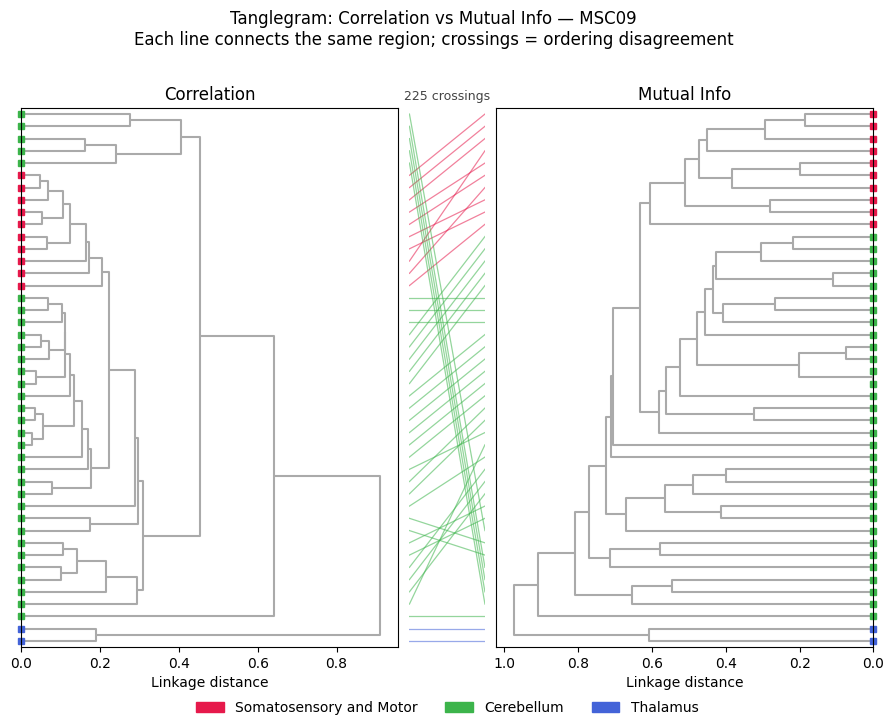

/var/folders/cf/4z622f6j29d4qx7rzj6l433m0000gp/T/ipykernel_35563/1076308386.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


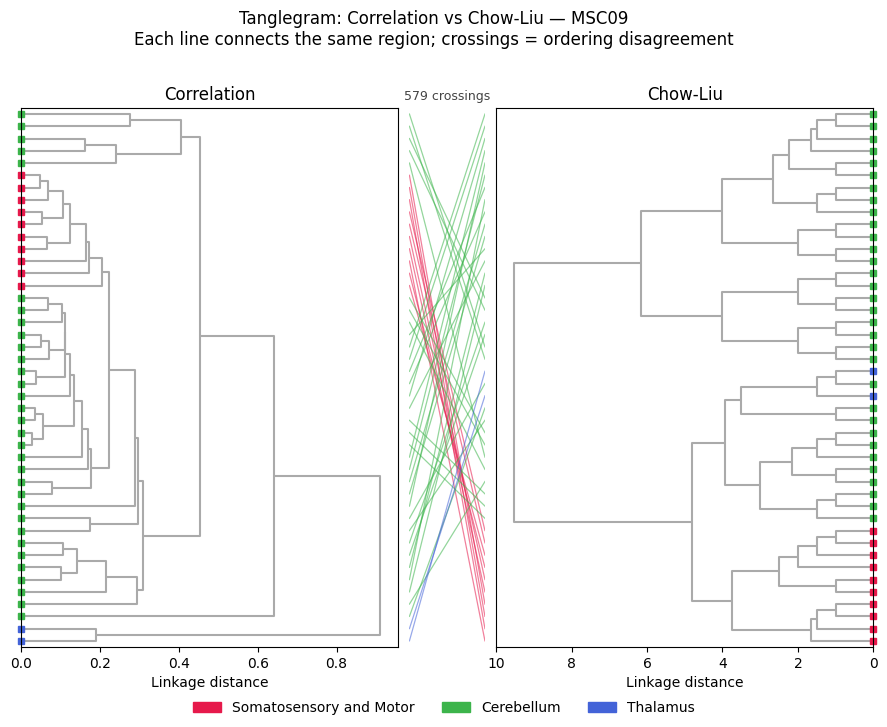

/var/folders/cf/4z622f6j29d4qx7rzj6l433m0000gp/T/ipykernel_35563/1076308386.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


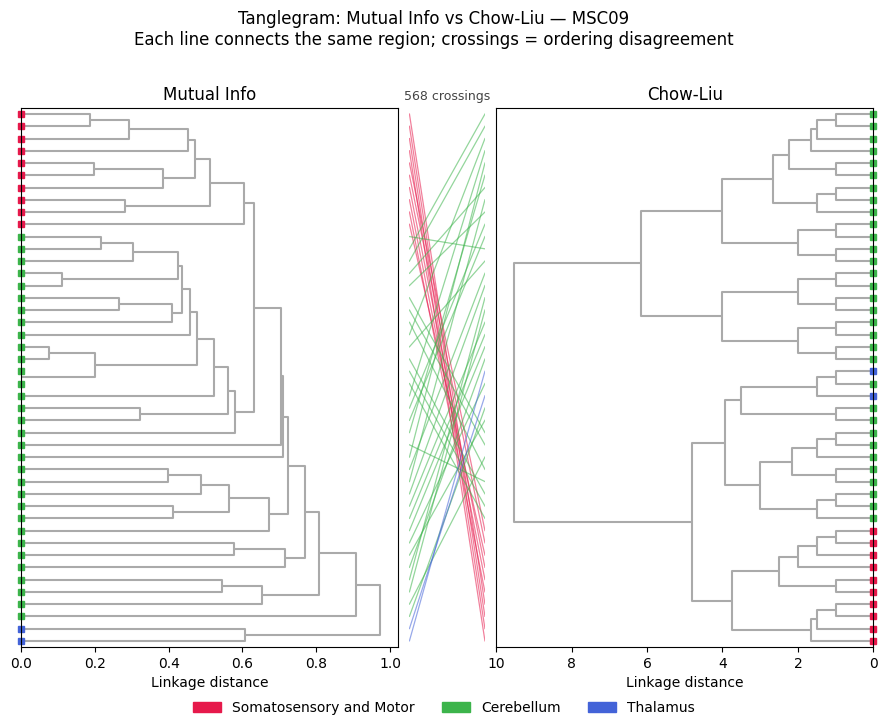

In [6]:
def draw_tanglegram(Z1, Z2, node_network_labels, network_colors,
                    title1='Method A', title2='Method B', figsize=(11, 7)):
    # Left panel:  Z1 orientation='right' (leaves face centre)
    # Right panel: Z2 orientation='left'  (leaves face centre)
    # Middle strip: colored lines connecting each region across both trees
    n   = len(node_network_labels)
    fig = plt.figure(figsize=figsize)
    gs  = gridspec.GridSpec(1, 3, width_ratios=[5, 1, 5], wspace=0.04)
    ax1    = fig.add_subplot(gs[0])
    ax_mid = fig.add_subplot(gs[1])
    ax2    = fig.add_subplot(gs[2])

    dend1 = dendrogram(Z1, ax=ax1, orientation='right',
                       color_threshold=0, above_threshold_color='#aaaaaa',
                       no_labels=True)
    dend2 = dendrogram(Z2, ax=ax2, orientation='left',
                       color_threshold=0, above_threshold_color='#aaaaaa',
                       no_labels=True)

    order1 = dend1['leaves']   # bottom-to-top
    order2 = dend2['leaves']

    # scipy leaf y-coords: 5, 15, 25, ...
    ypos1 = {leaf: 5 + 10 * i for i, leaf in enumerate(order1)}
    ypos2 = {leaf: 5 + 10 * i for i, leaf in enumerate(order2)}
    y_max = 10 * n

    ax_mid.set_xlim(0, 1)
    ax_mid.set_ylim(0, y_max)
    ax_mid.axis('off')

    for region_i in range(n):
        y1    = ypos1[region_i]
        y2    = ypos2[region_i]
        color = network_colors.get(node_network_labels[region_i], '#aaaaaa')
        ax_mid.plot([0, 1], [y1, y2], color=color, alpha=0.55, linewidth=0.9)

    for region_i in range(n):
        color = network_colors.get(node_network_labels[region_i], 'black')
        ax1.plot(0, ypos1[region_i], 's', color=color, markersize=4, clip_on=False)
        ax2.plot(0, ypos2[region_i], 's', color=color, markersize=4, clip_on=False)

    n_crossings = sum(
        1
        for i in range(n)
        for j in range(i + 1, n)
        if (ypos1[i] < ypos1[j]) != (ypos2[i] < ypos2[j])
    )

    ax1.set_title(title1, fontsize=12)
    ax2.set_title(title2, fontsize=12)
    ax1.set_yticks([]); ax2.set_yticks([])
    ax1.set_xlabel('Linkage distance'); ax2.set_xlabel('Linkage distance')
    ax_mid.text(0.5, 1.01, f'{n_crossings} crossings',
                ha='center', va='bottom', fontsize=9, color='#444444',
                transform=ax_mid.transAxes)
    return fig, n_crossings


subject = 'MSC09'
Z_corr, Z_mi, Z_cl = get_linkages(subject)

for Za, Zb, ta, tb in [
        (Z_corr, Z_mi,  'Correlation', 'Mutual Info'),
        (Z_corr, Z_cl,  'Correlation', 'Chow-Liu'),
        (Z_mi,   Z_cl,  'Mutual Info', 'Chow-Liu')]:
    fig, nc = draw_tanglegram(Za, Zb, node_network_labels, NETWORK_COLORS,
                               title1=ta, title2=tb)
    legend_patches = [mpatches.Patch(color=c, label=n.replace('_', ' '))
                      for n, c in NETWORK_COLORS.items()]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               fontsize=10, frameon=False)
    fig.suptitle(f'Tanglegram: {ta} vs {tb} — {subject}\n'
                  'Each line connects the same region; crossings = ordering disagreement',
                  fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f'fig2_tanglegram_{ta.replace(" ","_")}_{tb.replace(" ","_")}.pdf',
                bbox_inches='tight')
    plt.show()


---
## Figure 3 — Cophenetic distance scatter plots

**Idea:** For every pair of brain regions (i, j), compute the *cophenetic distance* —
the height in the dendrogram at which i and j first merge — under each method.
Plot Method A vs. Method B in a scatter.

- **Points on the diagonal** → both methods judge that pair equally similar.
- **Points above/below** → one method merges them earlier or later.
- **Red = within-network pairs; grey = between-network.**

Pearson r gives a single-number summary of overall structural agreement.

**Why it's better than the matrix:** Quantifies where methods agree/disagree and
separates within- from between-network errors in one plot.

In [7]:
def cophenetic_vec(Z):
    _, c = cophenet(Z)
    return c


def within_network_mask(node_network_labels):
    # Condensed bool vector: True if pair (i,j) is within the same network
    n   = len(node_network_labels)
    idx = np.triu_indices(n, k=1)
    return np.array(
        [node_network_labels[i] == node_network_labels[j]
         for i, j in zip(idx[0], idx[1])]
    )


subject = 'MSC09'
Z_corr, Z_mi, Z_cl = get_linkages(subject)

c_corr      = cophenetic_vec(Z_corr)
c_mi        = cophenetic_vec(Z_mi)
c_cl        = cophenetic_vec(Z_cl)
within_mask = within_network_mask(node_network_labels)

method_pairs = [
    (c_corr, c_mi,  'Correlation', 'Mutual Info'),
    (c_corr, c_cl,  'Correlation', 'Chow-Liu'),
    (c_mi,   c_cl,  'Mutual Info', 'Chow-Liu'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (cx, cy, lx, ly) in zip(axes, method_pairs):
    cx_n = (cx - cx.min()) / (cx.ptp() + 1e-12)
    cy_n = (cy - cy.min()) / (cy.ptp() + 1e-12)

    ax.scatter(cx_n[~within_mask], cy_n[~within_mask],
               s=6,  alpha=0.3, color='#aaaaaa', label='Between-network', rasterized=True)
    ax.scatter(cx_n[within_mask],  cy_n[within_mask],
               s=12, alpha=0.7, color='#e6194b', label='Within-network',  rasterized=True)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    r, _ = pearsonr(cx_n, cy_n)
    ax.text(0.05, 0.93, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11)

    ax.set_xlabel(f'{lx} cophenetic dist. (norm.)', fontsize=10)
    ax.set_ylabel(f'{ly} cophenetic dist. (norm.)', fontsize=10)
    ax.set_title(f'{lx} vs {ly}', fontsize=12)
    ax.set_aspect('equal')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

axes[0].legend(fontsize=9, frameon=False, markerscale=2)
fig.suptitle(f'Cophenetic distance agreement — {subject}\n'
              'Each point = one region pair; Pearson r = overall structural agreement',
              fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_cophenetic_scatter.pdf', bbox_inches='tight')
plt.show()


ValueError: too many values to unpack (expected 2)

---
## Figure 4 — Network coherence

**Idea:** Cut each dendrogram at k clusters, then for each *known* brain network ask:
what fraction of within-network region pairs ended up in the **same** cluster?

- Score = 1.0 → method perfectly respects that network at this k.
- Score ≈ 1/k → no better than chance.

Shown as (a) line plots across k for one subject, and (b) a heatmap at k = 3 for all subjects.

**Why it's better than the matrix:** Directly answers *"which method best recovers
motor cortex / cerebellum / thalamus organisation?"*

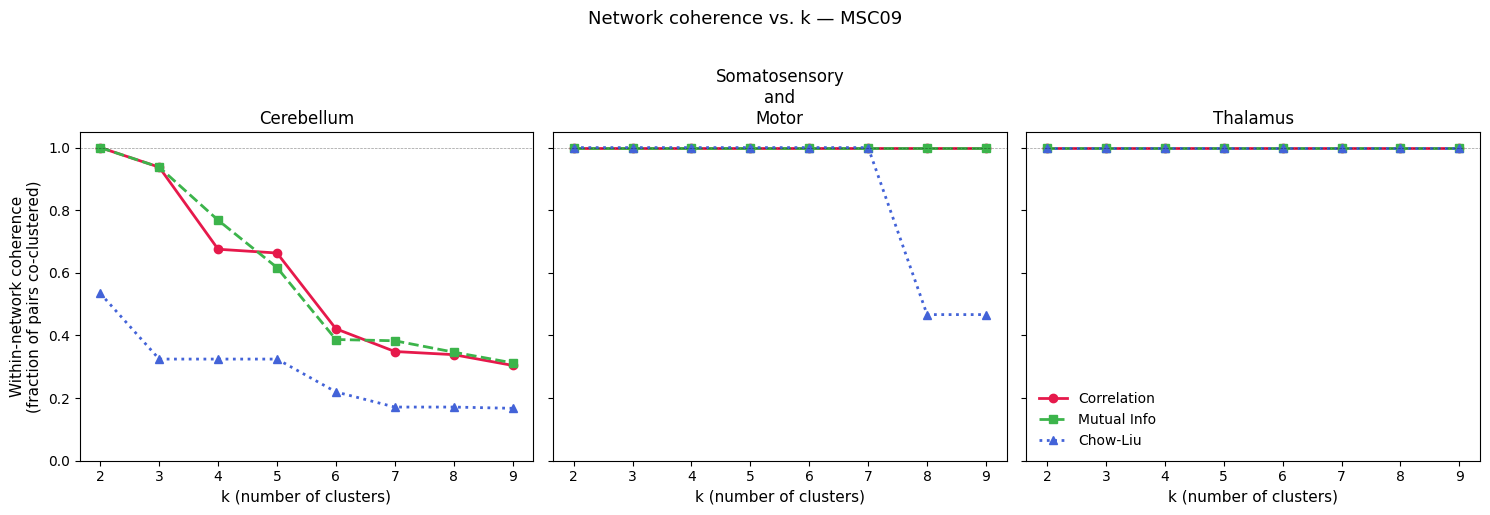

In [8]:
def network_coherence(Z, node_network_labels, k):
    # For each network, fraction of within-network pairs sharing a cluster at cut level k
    cluster_ids = fcluster(Z, t=k, criterion='maxclust')
    result = {}
    for net in sorted(set(node_network_labels)):
        idx = [i for i, n in enumerate(node_network_labels) if n == net]
        if len(idx) < 2:
            result[net] = np.nan
            continue
        same  = sum(cluster_ids[a] == cluster_ids[b]
                    for ai, a in enumerate(idx) for b in idx[ai + 1:])
        total = len(idx) * (len(idx) - 1) // 2
        result[net] = same / total
    return result


subject   = 'MSC09'
k_values  = list(range(2, 10))
networks  = sorted(set(node_network_labels))
Z_corr, Z_mi, Z_cl = get_linkages(subject)

method_labels   = ['Correlation', 'Mutual Info', 'Chow-Liu']
method_linkages = [Z_corr, Z_mi, Z_cl]
line_styles     = ['-o', '--s', ':^']
method_colors_l = ['#e6194b', '#3cb44b', '#4363d8']

fig, axes = plt.subplots(1, len(networks), figsize=(5 * len(networks), 5), sharey=True)

for ax, net in zip(axes, networks):
    for Z, label, ls, mc in zip(method_linkages, method_labels, line_styles, method_colors_l):
        vals = [network_coherence(Z, node_network_labels, k)[net] for k in k_values]
        ax.plot(k_values, vals, ls, color=mc, label=label, linewidth=2, markersize=6)
    ax.axhline(1.0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.set_xlabel('k (number of clusters)', fontsize=11)
    ax.set_title(net.replace('_', '\n'), fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(k_values)

axes[0].set_ylabel('Within-network coherence\n(fraction of pairs co-clustered)', fontsize=11)
axes[-1].legend(fontsize=10, frameon=False)
fig.suptitle(f'Network coherence vs. k — {subject}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig4a_network_coherence_lines.pdf', bbox_inches='tight')
plt.show()


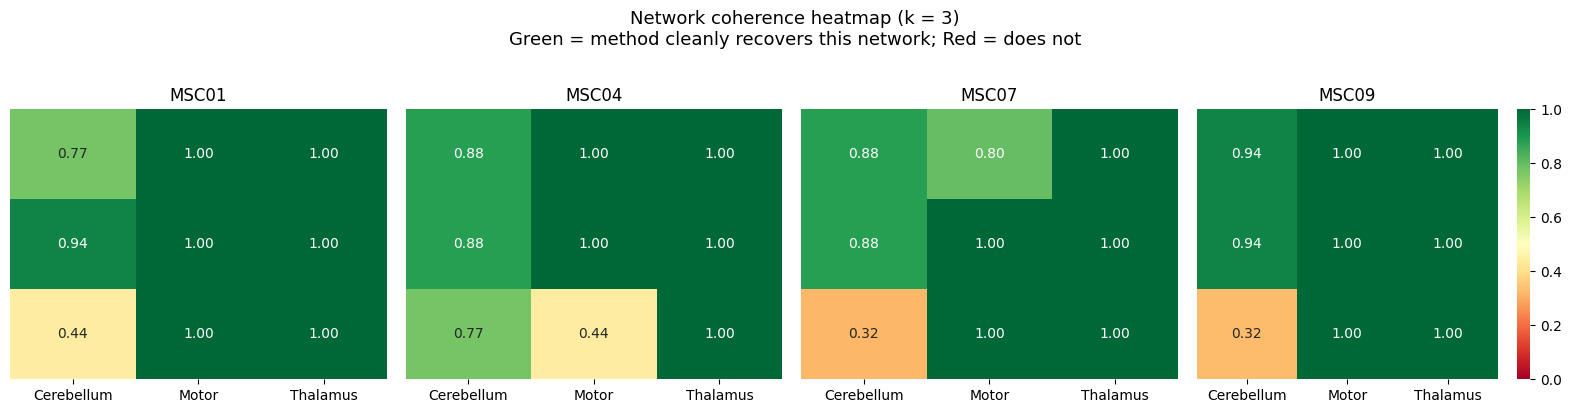

In [9]:
k_fixed = 3

fig, axes = plt.subplots(1, len(subjects), figsize=(4 * len(subjects), 4), sharey=True)

for ax, subj in zip(axes, subjects):
    Zc, Zm, Zcl = get_linkages(subj)
    table = np.zeros((3, len(networks)))
    for mi, Z in enumerate([Zc, Zm, Zcl]):
        coh = network_coherence(Z, node_network_labels, k_fixed)
        for ni, net in enumerate(networks):
            table[mi, ni] = coh[net]

    short_nets = [n.replace('Somatosensory_and_Motor', 'Motor') for n in networks]
    sns.heatmap(table, ax=ax,
                xticklabels=short_nets,
                yticklabels=method_labels if ax is axes[0] else False,
                vmin=0, vmax=1, cmap='RdYlGn',
                annot=True, fmt='.2f',
                cbar=(ax is axes[-1]))
    ax.set_title(subj, fontsize=12)

fig.suptitle(f'Network coherence heatmap (k = {k_fixed})\n'
              'Green = method cleanly recovers this network; Red = does not',
              fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig4b_coherence_heatmap.pdf', bbox_inches='tight')
plt.show()


---
## Figure 5 — Co-clustering agreement matrix

**Idea:** For each method at k = 3, build a binary N×N matrix where cell (i, j) = 1
if regions i and j share a cluster. Sum all three to get a **0–3 agreement matrix**:

- **3 (dark blue)** → all methods agree these regions belong together.
- **0 (white)** → all methods agree they are separated.
- **1–2 (grey)** → the methods are inconsistent — *these are the interesting cases*.

Rows/columns are sorted by the correlation dendrogram; red lines mark known network
boundaries. Accompanied by an ARI / NMI table for scalar reporting.

**Why it's better than the matrix:** A single image captures agreement *and* disagreement
simultaneously instead of requiring a mental diff of three separate matrices.

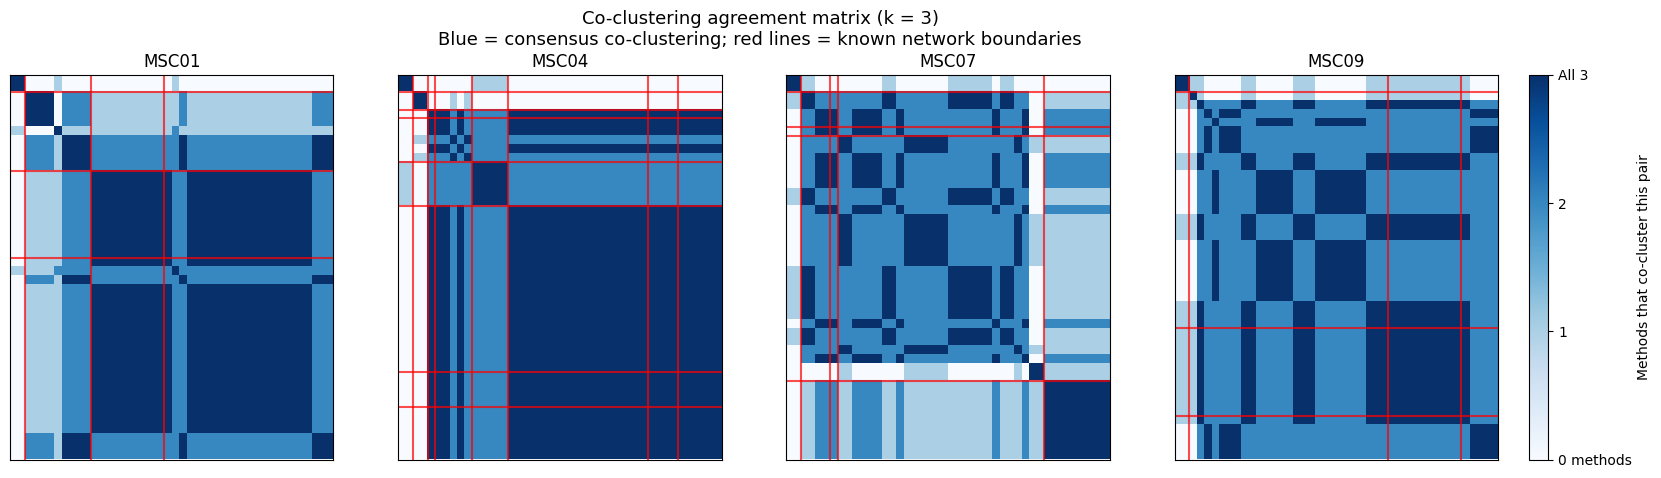

In [10]:
def same_cluster_matrix(Z, k):
    # Binary N x N matrix: 1 if two regions share a cluster when Z is cut at k
    labels = fcluster(Z, t=k, criterion='maxclust')
    return (labels[:, None] == labels[None, :]).astype(int)


k_fixed = 3

fig, axes = plt.subplots(1, len(subjects), figsize=(5 * len(subjects), 5))

im = None
for ax, subj in zip(axes, subjects):
    Zc, Zm, Zcl = get_linkages(subj)
    agreement = (same_cluster_matrix(Zc,  k_fixed)
                 + same_cluster_matrix(Zm,  k_fixed)
                 + same_cluster_matrix(Zcl, k_fixed))

    order            = leaves_list(Zc)
    agreement_sorted = agreement[np.ix_(order, order)]
    sorted_nets      = [node_network_labels[i] for i in order]

    im = ax.imshow(agreement_sorted, cmap='Blues', vmin=0, vmax=3,
                   aspect='auto', interpolation='nearest')

    for i in range(1, len(sorted_nets)):
        if sorted_nets[i] != sorted_nets[i - 1]:
            b = i - 0.5
            ax.axhline(b, color='red', linewidth=1.5, alpha=0.7)
            ax.axvline(b, color='red', linewidth=1.5, alpha=0.7)

    ax.set_title(subj, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

if im is not None:
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_ticks([0, 1, 2, 3])
    cbar.set_ticklabels(['0 methods', '1', '2', 'All 3'])
    cbar.set_label('Methods that co-cluster this pair', fontsize=10)

fig.suptitle(f'Co-clustering agreement matrix (k = {k_fixed})\n'
              'Blue = consensus co-clustering; red lines = known network boundaries',
              fontsize=13, y=1.01)
plt.savefig('fig5_coclustering_agreement.pdf', bbox_inches='tight')
plt.show()


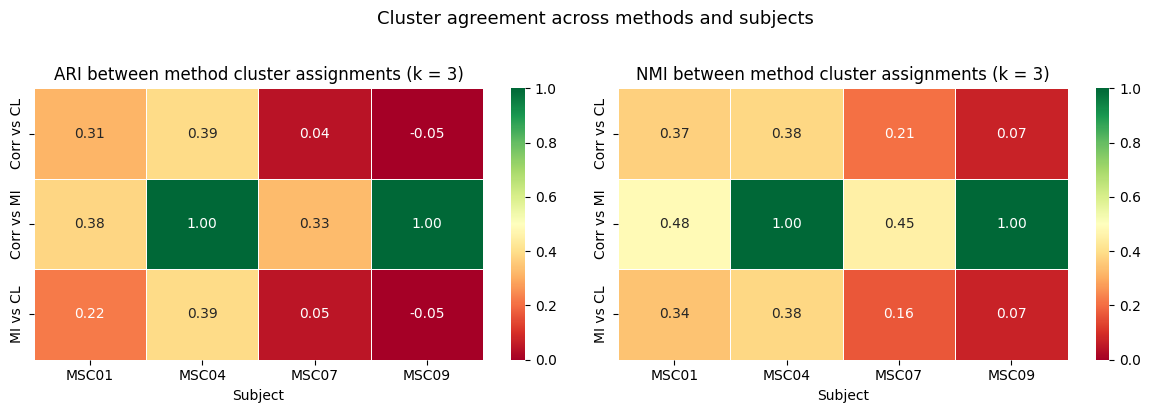

             mean           std       
              ARI    NMI    ARI    NMI
Pair                                  
Corr vs CL  0.174  0.257  0.213  0.148
Corr vs MI  0.677  0.733  0.374  0.308
MI vs CL    0.152  0.241  0.196  0.147


In [11]:
k_fixed = 3
records = []

for subj in subjects:
    Zc, Zm, Zcl = get_linkages(subj)
    lc  = fcluster(Zc,  k_fixed, criterion='maxclust')
    lm  = fcluster(Zm,  k_fixed, criterion='maxclust')
    lcl = fcluster(Zcl, k_fixed, criterion='maxclust')

    for la, lb, pair in [(lc, lm,  'Corr vs MI'),
                          (lc, lcl, 'Corr vs CL'),
                          (lm, lcl, 'MI vs CL')]:
        records.append({
            'Subject': subj, 'Pair': pair,
            'ARI': adjusted_rand_score(la, lb),
            'NMI': normalized_mutual_info_score(la, lb),
        })

df_agreement = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['ARI', 'NMI']):
    pivot = df_agreement.pivot(index='Pair', columns='Subject', values=metric)
    sns.heatmap(pivot, ax=ax, vmin=0, vmax=1, cmap='RdYlGn',
                annot=True, fmt='.2f', linewidths=0.5)
    ax.set_title(f'{metric} between method cluster assignments (k = {k_fixed})', fontsize=12)
    ax.set_ylabel('')

fig.suptitle('Cluster agreement across methods and subjects', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig5b_ari_nmi.pdf', bbox_inches='tight')
plt.show()

print(df_agreement.pivot_table(index='Pair', values=['ARI', 'NMI'],
                                aggfunc=['mean', 'std']).round(3))
